In [2]:
# 1. Install required packages (run once in your environment / notebook)
#!pip install gensim pyLDAvis spacy wordcloud

import re
import numpy as np
import pandas as pd
from pprint import pprint

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models import LsiModel
from gensim.models import TfidfModel
from wordcloud import WordCloud


# spaCy for better lemmatization
import spacy
import time
import os

# Plotting tools
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis   # use the gensim_models submodule
import matplotlib.pyplot as plt
%matplotlib inline

# Enable notebook display (essential in Jupyter)
pyLDAvis.enable_notebook()

# Optional: suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [3]:
# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================

import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


In [4]:
# 2. Load example data 
import pandas as pd

# Load the Amazon Electronics Reviews dataset
df = pd.read_csv("../data/processed/cleaned_reviews_latest.csv")

# Remove rows with missing review text
df = df.dropna(subset=["text"])

# Combine review title and review text (recommended)
df["review"] = df["title"].fillna("") + " " + df["text"].fillna("")

# Convert reviews to a list (same format as the demo)
data = df["review"].tolist()

print(f"Number of documents: {len(data)}")
print("Example document snippet:\n", data[0][:300], "...\n")

Number of documents: 10518
Example document snippet:
 Smells like gasoline! Going back! First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will want to pass on these.  Second: the phone adapter is useless as-is. Mine was not drilled far enough to be able to tighten it into place for my iPh ...



In [5]:
# 3. Preprocessing functions
# load spacy's small lanuage model that includes Tokenizer; POS tagger (part-of-speech);
# Lemmatizer; Dependency parser; Named Entity Recognizer (NER) without building dependency tree and
# detecting and labelling named entities (performance)

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def sent_to_words(sentences):
    """Tokenize and clean basic text"""
    for sentence in sentences:
        yield gensim.utils.simple_preprocess(str(sentence), deacc=True)  # lowercase, remove punct

def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(" ".join(doc))
             if word not in gensim.parsing.preprocessing.STOPWORDS]
            for doc in texts]

# specifying the words by their part-of-speech / grammatical category) that should be kept
def lemmatization(texts, allowed_postags=["NOUN", "ADJ", "VERB", "ADV"]):
    """Lemmatize with spaCy"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc
                          if token.pos_ in allowed_postags])
    return texts_out

# Apply preprocessing pipeline
data_words = list(sent_to_words(data))
data_words = remove_stopwords(data_words)
data_lemmatized = lemmatization(data_words)

print("\nExample after lemmatization:", data_lemmatized[0][:15])



Example after lemmatization: ['smell', 'gasoline', 'go', 'offensive', 'reek', 'gasoline', 'sensitive', 'allergic', 'petroleum', 'product', 'want', 'pass', 'second', 'phone', 'adapter']


In [6]:
# 4. Create Dictionary & Corpus
id2word = corpora.Dictionary(data_lemmatized)

# Filter extremes (very rare + very common words)
# Keep only tokens that appear in at least 15 documents (absolute number).
# Removes very rare words (hapax legomena, typos, very specific names, noise). These hurt topic
# quality because they don't generalize.
# Keep only tokens that appear in no more than 50% of all documents (fraction of total corpus size).
# Removes extremely common words (stopwords you missed, domain-specific boilerplate like "said",
# "report", "new", "year" in news data). These appear in almost every document, add no
# topic-discriminating power.

print(f"Original vocab size: {len(id2word)}")   # before filter
id2word.filter_extremes(no_below=5, no_above=0.4)
#print(f"After filtering: {len(id2word)} tokens remain")
#print("Most frequent remaining words:", id2word.most_common(10))

#id2word.filter_extremes(no_below=15, no_above=0.5)

#corpus = [id2word.doc2bow(text) for text in data_lemmatized]

#print(f"Number of unique tokens: {len(id2word)}")
#print(f"Number of documents in corpus: {len(corpus)}")
print(f"Original vocab size: {len(id2word)}")

# Filter only once
id2word.filter_extremes(no_below=5, no_above=0.4)

print(f"After filtering: {len(id2word)} tokens remain")
print("Most frequent remaining words:", id2word.most_common(10))

# Create corpus after filtering
corpus = [id2word.doc2bow(text) for text in data_lemmatized]

# TF-IDF Transformation

tfidf = TfidfModel(corpus)
corpus_tfidf = tfidf[corpus]

Original vocab size: 11125
Original vocab size: 3776
After filtering: 3776 tokens remain
Most frequent remaining words: [('work', 5660), ('great', 5019), ('good', 4125), ('use', 3600), ('need', 2572), ('easy', 2379), ('sound', 2286), ('love', 2112), ('time', 1970), ('quality', 1942)]


In [7]:
# 5. Train LSA model
# Common parameter to tune: num_topics
# LSA (Latent Semantic Analysis) is an algebraic topic modelling technique that
# applies Singular Value Decomposition (SVD) on a TF-IDF weighted term-document matrix.
# Unlike LDA, LSA does not use probabilistic modelling or iterative Bayesian learning.

# corpus_tfidf
# LSA works best on a TF-IDF weighted corpus rather than the raw Bag-of-Words corpus.
# TF-IDF reduces the influence of very common words and highlights more informative terms.

# num_topics
# Number of latent semantic dimensions (topics) to extract.
# This is the main parameter to tune.
# A very small number may merge unrelated topics,
# while a very large number may produce noisy or less interpretable topics.
# Typical values for a dataset of around 10,000 Amazon reviews are between 5 and 20.

# id2word
# Dictionary that maps word IDs to the original words.
# Used for displaying the most representative words for each latent topic.
topic_numbers = [5, 6, 7, 8, 9, 10]

lsa_models = {}

for num_topics in topic_numbers:

    print("\n" + "=" * 60)
    print(f"LSA MODEL: {num_topics} TOPICS")
    print("=" * 60)

    lsa_model = gensim.models.LsiModel(
        corpus=corpus_tfidf,
        id2word=id2word,
        num_topics=num_topics,
        random_seed = SEED
    )

    # Store the model
    lsa_models[num_topics] = lsa_model

    # Print model information
    print(lsa_model)

    # Print the keywords in each topic
    pprint(lsa_model.print_topics(num_words=8))

# Output Interpretation
# Topic ID (0, 1, 2, …):
#     Index assigned to each latent topic.

# Weights (e.g., 0.453, -0.327):
#     Positive values indicate words that contribute positively to the topic.
#     Negative values indicate words contributing in the opposite semantic direction.
#     Unlike LDA, these are NOT probabilities.
#     They are coefficients obtained from Singular Value Decomposition (SVD).

# Words:
#     The most representative terms describing each latent semantic topic.


LSA MODEL: 5 TOPICS
LsiModel<num_terms=3776, num_topics=5, decay=1.0, chunksize=20000>
[(0,
  '0.331*"great" + 0.272*"work" + 0.259*"star" + 0.218*"good" + 0.192*"love" + '
  '0.180*"product" + 0.150*"quality" + 0.149*"sound"'),
 (1,
  '-0.922*"star" + 0.073*"cable" + 0.068*"charge" + -0.063*"love" + '
  '0.063*"use" + 0.059*"easy" + 0.053*"phone" + 0.051*"case"'),
 (2,
  '0.608*"great" + 0.387*"work" + 0.285*"product" + -0.234*"star" + '
  '0.148*"price" + -0.125*"case" + -0.106*"camera" + -0.096*"cable"'),
 (3,
  '0.713*"love" + -0.339*"work" + 0.263*"case" + -0.248*"cable" + '
  '0.140*"perfect" + -0.139*"good" + 0.116*"ipad" + 0.112*"fit"'),
 (4,
  '-0.485*"work" + 0.413*"good" + 0.359*"sound" + 0.334*"quality" + '
  '0.224*"product" + 0.205*"price" + -0.203*"perfect" + 0.159*"speaker"')]

LSA MODEL: 6 TOPICS
LsiModel<num_terms=3776, num_topics=6, decay=1.0, chunksize=20000>
[(0,
  '-0.331*"great" + -0.272*"work" + -0.259*"star" + -0.218*"good" + '
  '-0.192*"love" + -0.180*"produ

In [8]:
# ============================================================
# 9. CALCULATE c_v COHERENCE
# ============================================================

lsa_coherence_scores = []

for num_topics, model in lsa_models.items():

    coherence_model = CoherenceModel(
        model=model,
        texts=data_lemmatized,
        dictionary=id2word,
        coherence="c_v"
    )

    coherence = (
        coherence_model.get_coherence()
    )

    lsa_coherence_scores.append({
        "Number of Topics": num_topics,
        "Coherence Score": coherence
    })

    print(
        f"{num_topics} topics: "
        f"{coherence:.6f}"
    )


lsa_results = pd.DataFrame(
    lsa_coherence_scores
)

print("\nLSA Coherence Results:")
print(lsa_results)

5 topics: 0.364565
6 topics: 0.456721
7 topics: 0.342771
8 topics: 0.368029
9 topics: 0.376619
10 topics: 0.373322

LSA Coherence Results:
   Number of Topics  Coherence Score
0                 5         0.364565
1                 6         0.456721
2                 7         0.342771
3                 8         0.368029
4                 9         0.376619
5                10         0.373322


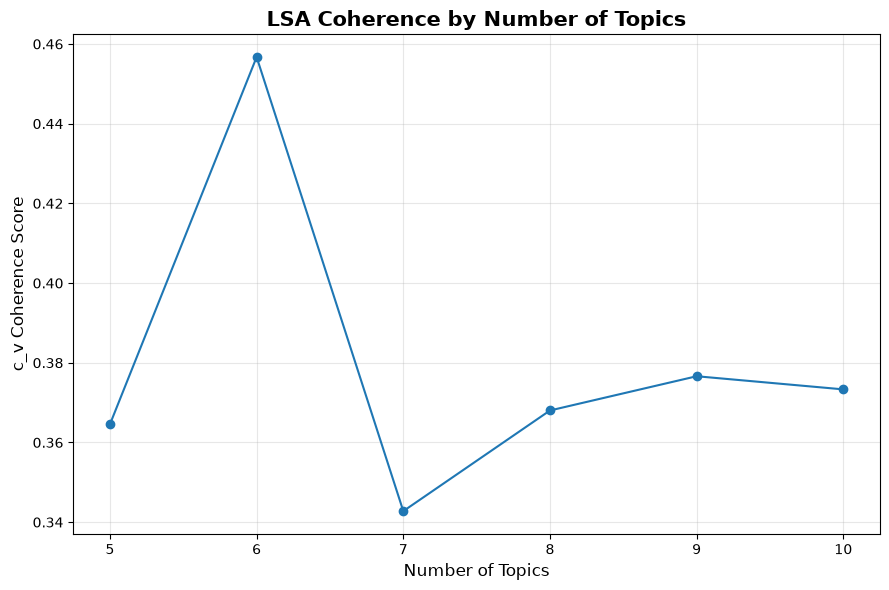

In [11]:
# ============================================================
# 11. COHERENCE BY NUMBER OF TOPICS
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    lsa_results["Number of Topics"],
    lsa_results["Coherence Score"],
    marker="o"
)

plt.xlabel(
    "Number of Topics",
    fontsize=12
)

plt.ylabel(
    "c_v Coherence Score",
    fontsize=12
)

plt.title(
    "LSA Coherence by Number of Topics",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    topic_numbers
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../visualizations/LSA_Coherence_Topic_Number.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ============================================================
# 12. SELECT BEST NUMBER OF TOPICS
# ============================================================

best_row = lsa_results.loc[
    lsa_results["Coherence Score"].idxmax()
]

BEST_TOPICS = int(
    best_row["Number of Topics"]
)

BEST_COHERENCE = (
    best_row["Coherence Score"]
)

print(
    f"Best number of topics: {BEST_TOPICS}"
)

print(
    f"Best coherence score: "
    f"{BEST_COHERENCE:.6f}"
)

Best number of topics: 6
Best coherence score: 0.456721


In [13]:
# ============================================================
# 13. TRAIN FINAL LSA MODEL
# ============================================================

start_time = time.time()

lsa_model_final = gensim.models.LsiModel(
    corpus=corpus_tfidf,
    id2word=id2word,
    num_topics=BEST_TOPICS,
    random_seed=SEED
)

end_time = time.time()

training_time = (
    end_time - start_time
)

print(
    f"Final LSA model: "
    f"{BEST_TOPICS} topics"
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print(
    f"Training time: "
    f"{training_time / 60:.2f} minutes"
)

Final LSA model: 6 topics
Training time: 3.25 seconds
Training time: 0.05 minutes


In [14]:
# ============================================================
# 14. DISPLAY FINAL LSA TOPICS
# ============================================================

for idx, topic in lsa_model_final.print_topics(
    num_words=10
):

    print("\n")
    print(
        f"Topic {idx + 1}"
    )

    print(topic)



Topic 1
-0.331*"great" + -0.272*"work" + -0.259*"star" + -0.218*"good" + -0.192*"love" + -0.180*"product" + -0.150*"quality" + -0.150*"sound" + -0.149*"price" + -0.138*"easy"


Topic 2
-0.922*"star" + 0.073*"cable" + 0.068*"charge" + -0.063*"love" + 0.063*"use" + 0.058*"easy" + 0.053*"phone" + 0.051*"case" + 0.047*"camera" + 0.046*"battery"


Topic 3
-0.607*"great" + -0.388*"work" + -0.286*"product" + 0.234*"star" + -0.147*"price" + 0.126*"case" + 0.106*"camera" + 0.095*"cable" + -0.091*"value" + 0.090*"charge"


Topic 4
0.714*"love" + -0.337*"work" + 0.264*"case" + -0.246*"cable" + 0.141*"perfect" + -0.139*"good" + 0.116*"ipad" + 0.114*"fit" + 0.100*"great" + 0.099*"cover"


Topic 5
-0.485*"work" + 0.413*"good" + 0.357*"sound" + 0.335*"quality" + 0.225*"product" + 0.205*"price" + -0.203*"perfect" + 0.159*"speaker" + -0.121*"need" + 0.110*"headphone"


Topic 6
-0.515*"love" + 0.323*"case" + -0.318*"cable" + 0.303*"perfect" + 0.244*"fit" + -0.190*"sound" + 0.183*"good" + 0.177*"ipad" 

In [15]:
# ============================================================
# 15. FINAL MODEL COHERENCE
# ============================================================

final_coherence_model = CoherenceModel(
    model=lsa_model_final,
    texts=data_lemmatized,
    dictionary=id2word,
    coherence="c_v"
)

final_coherence = (
    final_coherence_model.get_coherence()
)

print(
    f"Final LSA coherence: "
    f"{final_coherence:.6f}"
)

Final LSA coherence: 0.456721


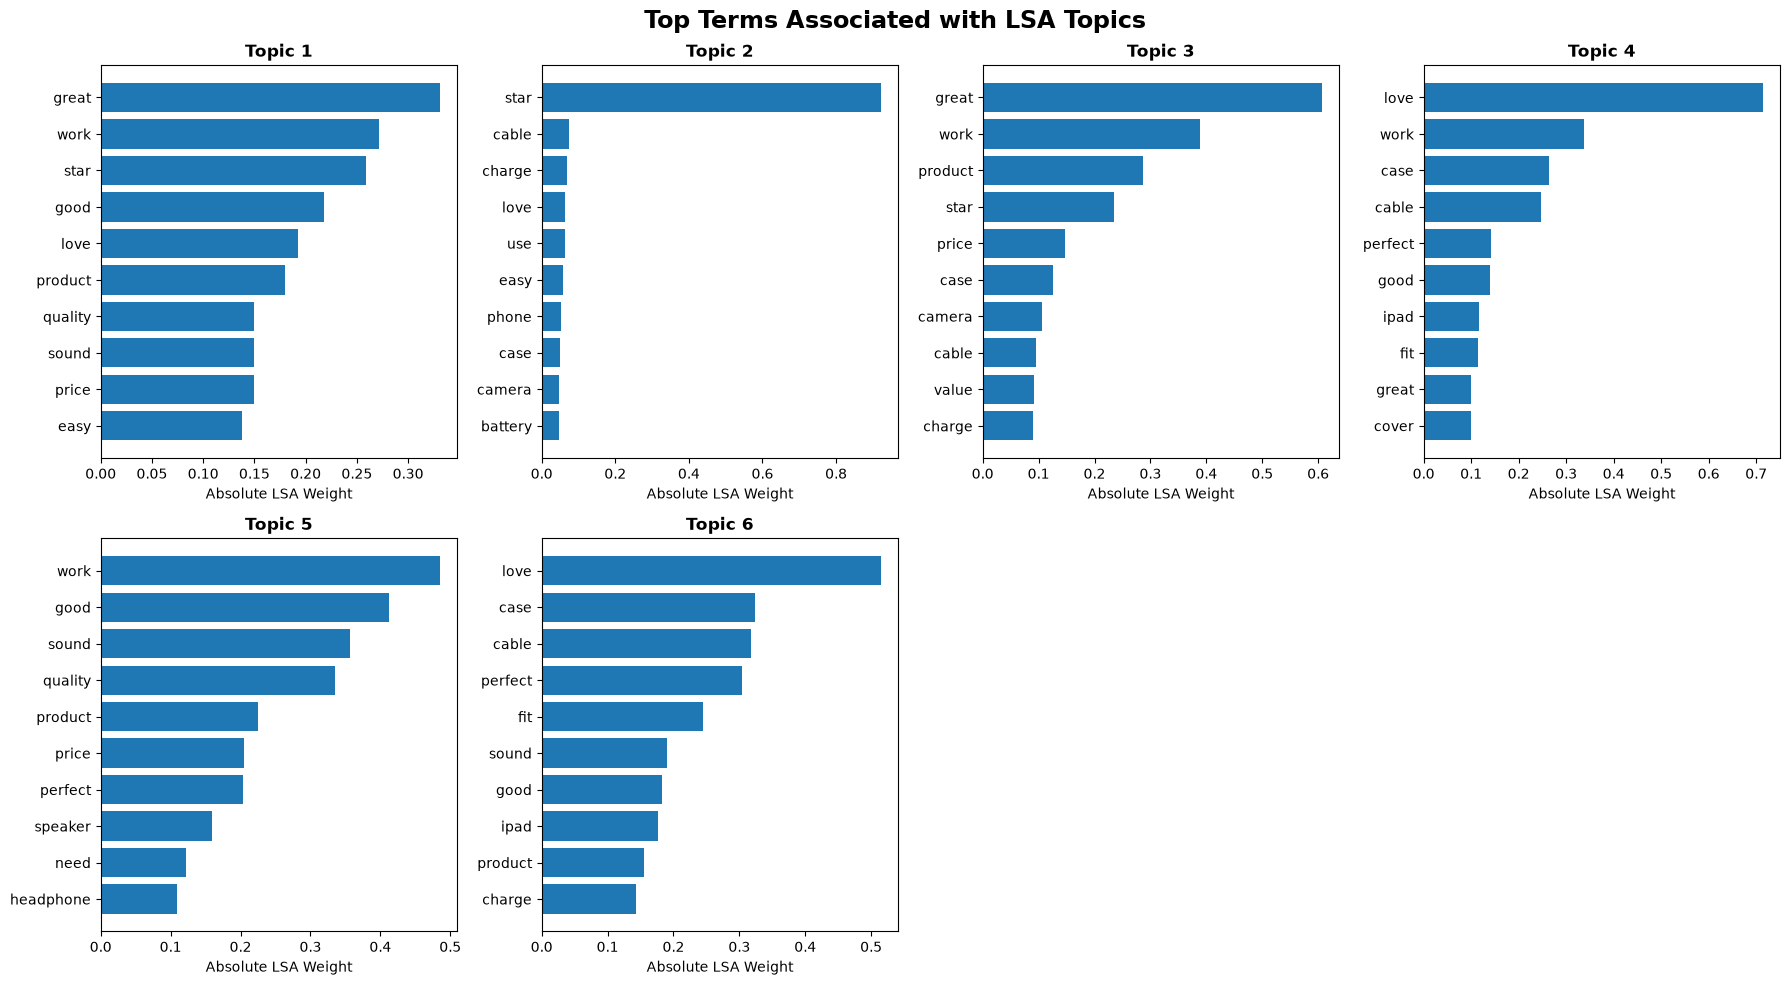

In [17]:
# ============================================================
# 16. TOP-TERM BAR CHART
# ============================================================

num_words = 10

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 10)
)

axes = axes.flatten()

for topic_id in range(BEST_TOPICS):

    topic_terms = (
        lsa_model_final.show_topic(
            topic_id,
            topn=num_words
        )
    )

    words = [
        word
        for word, weight in topic_terms
    ]

    weights = [
        abs(weight)
        for word, weight in topic_terms
    ]

    words = words[::-1]
    weights = weights[::-1]

    axes[topic_id].barh(
        words,
        weights
    )

    axes[topic_id].set_title(
        f"Topic {topic_id + 1}",
        fontweight="bold"
    )

    axes[topic_id].set_xlabel(
        "Absolute LSA Weight"
    )

# Hide unused subplot if there are 8 topics
for i in range(BEST_TOPICS, len(axes)):
    axes[i].axis("off")

fig.suptitle(
    "Top Terms Associated with LSA Topics",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/LSA_Top_Terms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

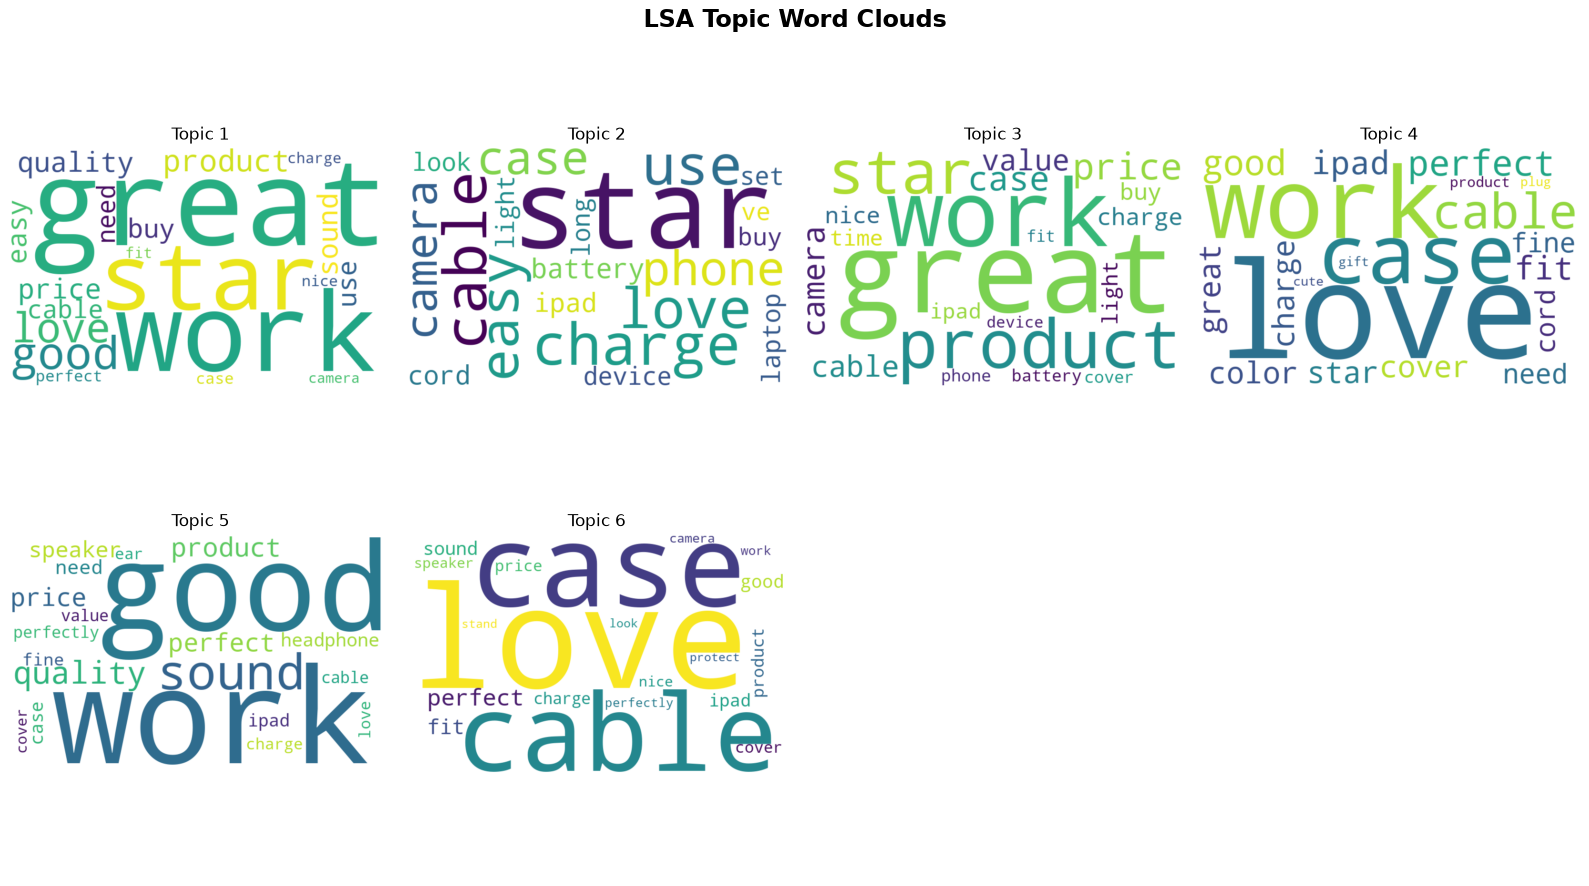

In [18]:
# ============================================================
# 17. LSA TOPIC WORD CLOUDS
# ============================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 9)
)

axes = axes.flatten()

for topic_id in range(BEST_TOPICS):

    topic_words = (
        lsa_model_final.show_topic(
            topic_id,
            topn=20
        )
    )

    word_weights = dict(
        topic_words
    )

    wc = WordCloud(
        width=800,
        height=500,
        background_color="white"
    ).generate_from_frequencies(
        {
            word: abs(weight)
            for word, weight in word_weights.items()
        }
    )

    axes[topic_id].imshow(
        wc,
        interpolation="bilinear"
    )

    axes[topic_id].axis("off")

    axes[topic_id].set_title(
        f"Topic {topic_id + 1}"
    )

for i in range(BEST_TOPICS, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "LSA Topic Word Clouds",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../visualizations/LSA_Topic_Wordclouds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# ============================================================
# 18. MEMORY USAGE
# ============================================================

import psutil
import os

process = psutil.Process(os.getpid())

memory_mb = process.memory_info().rss / (1024 * 1024)

print(f"Current Python process memory: {memory_mb:.2f} MB")

Current Python process memory: 582.34 MB


In [20]:
# ============================================================
# 19. LSA SCALABILITY TEST
# ============================================================
import time
import gensim
from gensim.models import CoherenceModel
dataset_sizes = [
    2000,
    5000,
    7500,
    10518
]

lsa_scalability_results = []

for size in dataset_sizes:

    print("\n" + "=" * 60)
    print(
        f"LSA SCALABILITY TEST: {size} REVIEWS"
    )
    print("=" * 60)

    # Select subset
    subset = data_lemmatized[:size]

    # Create dictionary
    subset_id2word = (
        gensim.corpora.Dictionary(
            subset
        )
    )

    # Same vocabulary filtering
    subset_id2word.filter_extremes(
        no_below=5,
        no_above=0.4
    )

    # Create BoW corpus
    subset_corpus = [
        subset_id2word.doc2bow(text)
        for text in subset
    ]

    # TF-IDF
    subset_tfidf = TfidfModel(
        subset_corpus
    )

    subset_corpus_tfidf = (
        subset_tfidf[
            subset_corpus
        ]
    )

    # Train LSA
    start_time = time.time()

    lsa_scalability_model = (
        gensim.models.LsiModel(
            corpus=subset_corpus_tfidf,
            id2word=subset_id2word,
            num_topics=BEST_TOPICS,
            random_seed=SEED
        )
    )

    end_time = time.time()

    training_time = (
        end_time - start_time
    )

    # Coherence
    coherence_model = CoherenceModel(
        model=lsa_scalability_model,
        texts=subset,
        dictionary=subset_id2word,
        coherence="c_v"
    )

    coherence = (
        coherence_model.get_coherence()
    )

    # Store results
    lsa_scalability_results.append({
        "Dataset Size": size,
        "Vocabulary Size": len(
            subset_id2word
        ),
        "Training Time (seconds)": training_time,
        "Training Time (minutes)": (
            training_time / 60
        ),
        "Coherence": coherence
    })

    print(
        f"Vocabulary size: "
        f"{len(subset_id2word)}"
    )

    print(
        f"Training time: "
        f"{training_time:.2f} seconds"
    )

    print(
        f"Coherence: "
        f"{coherence:.4f}"
    )


LSA SCALABILITY TEST: 2000 REVIEWS
Vocabulary size: 1331
Training time: 0.65 seconds
Coherence: 0.4008

LSA SCALABILITY TEST: 5000 REVIEWS
Vocabulary size: 2663
Training time: 1.51 seconds
Coherence: 0.3605

LSA SCALABILITY TEST: 7500 REVIEWS
Vocabulary size: 3496
Training time: 2.44 seconds
Coherence: 0.3397

LSA SCALABILITY TEST: 10518 REVIEWS
Vocabulary size: 3776
Training time: 3.20 seconds
Coherence: 0.4567


In [21]:
# ============================================================
# 20. SCALABILITY RESULTS TABLE
# ============================================================

lsa_scalability_df = pd.DataFrame(
    lsa_scalability_results
)

lsa_scalability_df

,Dataset Size,Vocabulary Size,Training Time (seconds),Training Time (minutes),Coherence
0,2000,1331,0.650338,0.010839,0.400849
1,5000,2663,1.505816,0.025097,0.360532
2,7500,3496,2.436461,0.040608,0.339718
3,10518,3776,3.203721,0.053395,0.456721


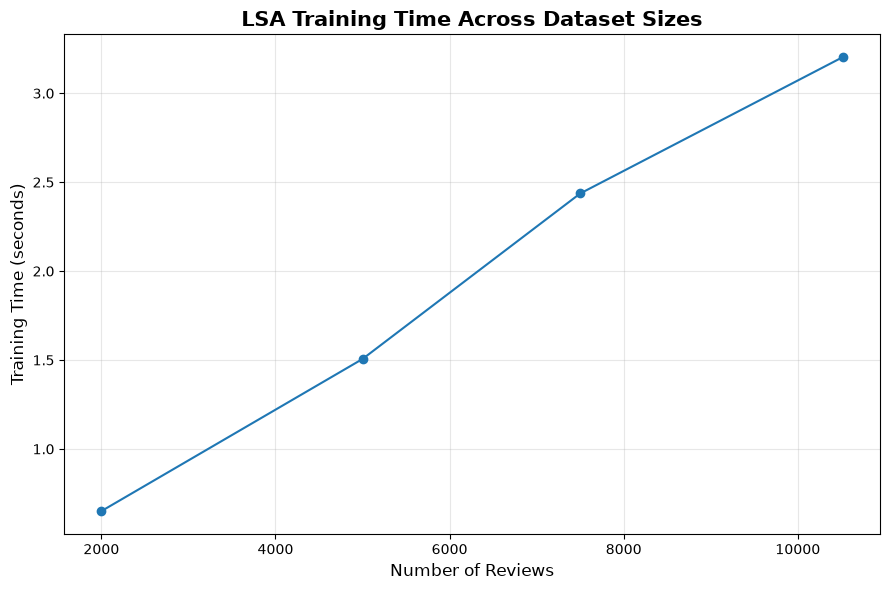

In [22]:
# ============================================================
# 21. TRAINING TIME VS DATASET SIZE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    lsa_scalability_df["Dataset Size"],
    lsa_scalability_df[
        "Training Time (seconds)"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Reviews",
    fontsize=12
)

plt.ylabel(
    "Training Time (seconds)",
    fontsize=12
)

plt.title(
    "LSA Training Time Across Dataset Sizes",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "LSA_Training_Time_Scalability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

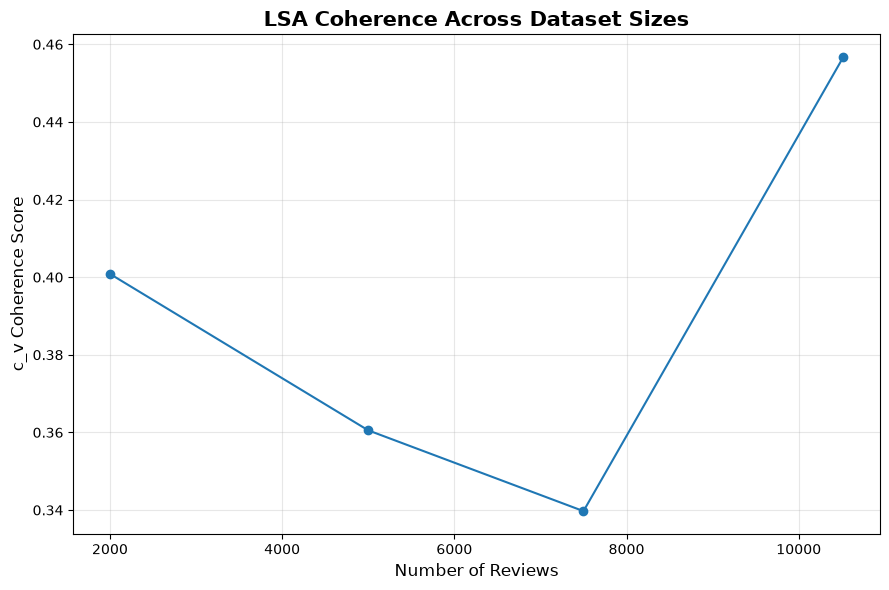

In [26]:
# ============================================================
# 22. COHERENCE VS DATASET SIZE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    lsa_scalability_df["Dataset Size"],
    lsa_scalability_df["Coherence"],
    marker="o"
)

plt.xlabel(
    "Number of Reviews",
    fontsize=12
)

plt.ylabel(
    "c_v Coherence Score",
    fontsize=12
)

plt.title(
    "LSA Coherence Across Dataset Sizes",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../visualizations/LSA_Coherence_Scalability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# ============================================================
# 23. FINAL LSA SUMMARY
# ============================================================

print("=" * 60)
print("FINAL LSA MODEL SUMMARY")
print("=" * 60)

print(
    f"Dataset size: {len(data)} reviews"
)

print(
    f"Vocabulary size: {len(id2word)}"
)

print(
    f"Optimal number of topics: "
    f"{BEST_TOPICS}"
)

print(
    f"Final coherence: "
    f"{final_coherence:.6f}"
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print(
    f"Training time: "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Memory usage: "
    f"{memory_mb:.2f} MB"
)

FINAL LSA MODEL SUMMARY
Dataset size: 10518 reviews
Vocabulary size: 3776
Optimal number of topics: 6
Final coherence: 0.456721
Training time: 3.20 seconds
Training time: 0.05 minutes
Memory usage: 582.34 MB
